<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Tomás Vallejo
- Nombre de alumno 2:

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [12]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly

Resolved 146 packages in 587ms                                       
⠙ Preparing packages... (0/1)                                                   ⠋ Preparing packages... (0/0)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/415.58 KiB          
⠙ Preparing packages... (0/1)------------------- 16.00 KiB/415.58 KiB        
⠙ Preparing packages... (0/1)------------------- 32.00 KiB/415.58 KiB        
⠙ Preparing packages... (0/1)------------------- 48.00 KiB/415.58 KiB        
⠙ Preparing packages... (0/1)------------------- 63.29 KiB/415.58 KiB        
⠙ Preparing packages... (0/1)------------------- 79.29 KiB/415.58 KiB        
⠙ Preparing packages... (0/1)------------------- 95.29 KiB/415.58 KiB        
⠙ Preparing packages... (0/1)------------------- 111.29 KiB/415.58 KiB       
⠙ Preparing packages... (0/1)------------------- 127.29 KiB/415.58 KiB       
⠙ Preparing packages... (0/1)------------------- 143.29 KiB/415.58 

In [13]:
import warnings

import nltk
import optuna
import pandas as pd
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [14]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [15]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [16]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [17]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [18]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?



1. Un baseline en Machine Learning es un modelo de referencia mínimo que establece el piso de rendimiento que cualquier modelo más sofisticado debería superar. Nos sirve para contextualizar si un modelo complejo realmente está aprendiendo algo útil o si simplemente está capturando la distribución de clases. 

2. Usamos un `DummyClassifier` como baseline porque predice respetando la distribución de clases del dataset sin aprender ningún patrón real. Si un modelo real no logra superarlo, significa que no está aprendiendo nada útil y probablemente hay un problema con los datos, las features o el modelo.

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

X = df_comics.drop(columns=["alignment"])
y = df_comics["alignment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Pipeline DecisionTree
pipe_dt = Pipeline(
    steps=[
        ("features", preprocessing_transformer),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)
pipe_dt.fit(X_train, y_train)
print("=== DecisionTreeClassifier ===")
print(classification_report(y_test, pipe_dt.predict(X_test)))

# Baseline DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
print("=== DummyClassifier ===")
print(classification_report(y_test, dummy.predict(X_test)))

=== DecisionTreeClassifier ===
              precision    recall  f1-score   support

         Bad       0.47      0.48      0.47        86
        Good       0.68      0.64      0.66       148
     Neutral       0.10      0.13      0.12        23

    accuracy                           0.54       257
   macro avg       0.42      0.42      0.42       257
weighted avg       0.56      0.54      0.55       257

=== DummyClassifier ===
              precision    recall  f1-score   support

         Bad       0.32      0.34      0.33        86
        Good       0.58      0.56      0.57       148
     Neutral       0.12      0.13      0.12        23

    accuracy                           0.45       257
   macro avg       0.34      0.34      0.34       257
weighted avg       0.46      0.45      0.45       257



### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?


Se ve que el `DecisionTreeClassifier` sí supera al `DummyClassifier`: obtiene accuracy de 0.54 vs 0.45 y al ser un problema desbalanceado nos fijamos en F1-Macro de 0.42 vs 0.34, lo que indica que el modelo está aprendiendo algunos patrones reales del texto e información numérica. Sin embargo el desempeño sigue siendo bajo, especialmente en la clase Neutral (F1=0.12) que es la más pequeña, lo que sugiere que hay bastante margen de mejora.

1. En este ejemplo de clases desbalanceadas la métrica de el accuracy es el típico ejemplo engañoso: hay 148 Good, 86 Bad y solo 23 Neutral en test. Un modelo que prediga siempre Good tendría accuracy de 58% aproximadamente sin aprender realmente nada útil. La métrica más apropiada en este caso es F1-Macro, que promedia el F1 de cada clase por igual sin importar su tamaño, penalizando el mal desempeño en clases minoritarias como la Neutral que se mencionó anteriormente.

2. El parámetro `stratify=y` en `train_test_split` garantiza que las proporciones de cada clase se mantengan tanto en train como en test. Sin él, podría ocurrir que por azar casi todos los Neutral quedaran en train y el modelo nunca viera ejemplos de esa clase en test, o viceversa, lo que haría la evaluación poco representativa, por lo que en este tipo de problemas con clases desbalanceadas es absolutamente necesario el uso de este parámetro.

3. Sí, el clasificador es mejor que su versión aleatoria en todas las métricas. Podemos avanzar con cierta confianza de que está clasificando mejor que lanzar un dado de 3 caras, aunque el desempeño en Neutral es casi igual al Dummy (0.12 vs 0.12), lo que indica que es completamente necesario el uso de modelos más sofisticados para mejorar realmente en esa clase.

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?


El Bagging funciona en tres pasos: 

1. Primero, a partir del dataset original se generan múltiples subconjuntos de entrenamiento mediante muestreo con reemplazo (bootstrap), lo que se traduce en que cada subconjunto tiene el mismo tamaño que el original pero algunas instancias pueden repetirse y otras quedar fuera. 

2. Segundo, sobre cada subconjunto se entrena un modelo independiente, en el caso de Random Forest son árboles de decisión de forma completamente paralela y sin que un modelo sepa lo que aprendió el otro. 

3. Tercero, para predecir se combinan las predicciones de todos los modelos mediante votación mayoritaria en clasificación: la clase que más modelos predigan es la predicción final. 

La idea central es que al entrenar modelos distintos sobre datos distintos y combinarlos, los errores individuales se compensan entre sí, resultando en un modelo más robusto que cualquier árbol individual.

---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [24]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(
    steps=[
        ("features", preprocessing_transformer),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]
)
pipe_rf.fit(X_train, y_train)
print("=== RandomForestClassifier ===")
print(classification_report(y_test, pipe_rf.predict(X_test)))

=== RandomForestClassifier ===
              precision    recall  f1-score   support

         Bad       0.67      0.35      0.46        86
        Good       0.66      0.93      0.77       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.65       257
   macro avg       0.44      0.43      0.41       257
weighted avg       0.60      0.65      0.60       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.


Se evidencia que el Random Forest mejoró en accuracy (0.65 vs 0.54) y en la clase Good (F1=0.77 vs 0.66), pero el F1-Macro bajó levemente respecto al DecisionTree (0.41 vs 0.42). Esto se debe a que Random Forest clasificó absolutamente todos los Neutral como otra clase (F1=0.00), lo que penaliza fuertemente el promedio macro. La mejora en accuracy se explica porque el modelo aprendió muy bien la clase mayoritaria Good (recall=0.93), pero al ser una clase tan dominante esto no refleja un mejor aprendizaje general. Esto confirma que el desbalance de clases es el principal desafío, Random Forest al combinar 100 árboles tiende a especializarse en las clases

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.


El Boosting es una técnica de ensamblaje que, a diferencia del Bagging, entrena los modelos de forma secuencial donde cada modelo nuevo intenta corregir los errores del anterior.

1. En Boosting los modelos se entrenan uno después del otro, no en paralelo como en Bagging. Cada modelo depende del anterior ya que necesita saber dónde se equivocó para enfocarse en esos casos.

2. Cada modelo nuevo recibe información sobre qué instancias el modelo anterior clasificó mal, asignándoles mayor peso para que el siguiente árbol se enfoque más en ellas. De esta forma cada árbol se especializa en los errores que los anteriores no pudieron resolver.

3. Las predicciones no se combinan por votación simple sino por una suma ponderada donde los modelos con mejor desempeño tienen mayor peso en la decisión final.

XGBoost y LightGBM son ambas implementaciones de Boosting basadas en árboles pero con diferencias de implementación: XGBoost construye los árboles por niveles mientras que LightGBM los construye por hojas, lo que lo hace más rápido y eficiente en memoria. Esto también explica por qué XGBoost requiere que las etiquetas sean numéricas, ya que su implementación interna opera directamente con índices numéricos para las clases, mientras que LightGBM tiene una capa adicional que maneja strings directamente convirtiéndolos internamente.

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [25]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# LabelEncoder para XGBoost que requiere etiquetas numéricas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Pipeline XGBoost
pipe_xgb = Pipeline(
    steps=[
        ("features", preprocessing_transformer),
        ("clf", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)),
    ]
)
pipe_xgb.fit(X_train, y_train_enc)
print("=== XGBClassifier ===")
print(classification_report(y_test_enc, pipe_xgb.predict(X_test), target_names=le.classes_))

# Pipeline LightGBM
pipe_lgbm = Pipeline(
    steps=[
        ("features", preprocessing_transformer),
        ("clf", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
    ]
)
pipe_lgbm.fit(X_train, y_train)
print("=== LGBMClassifier ===")
print(classification_report(y_test, pipe_lgbm.predict(X_test)))

=== XGBClassifier ===
              precision    recall  f1-score   support

         Bad       0.56      0.42      0.48        86
        Good       0.68      0.84      0.75       148
     Neutral       0.50      0.17      0.26        23

    accuracy                           0.64       257
   macro avg       0.58      0.48      0.50       257
weighted avg       0.62      0.64      0.62       257

=== LGBMClassifier ===
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?


XGBoost obtuvo un F1-Macro de 0.50 mientras que LightGBM obtuvo 0.45, por lo que XGBoost tuvo mejor desempeño en esta métrica. Aunque LightGBM obtuvo mayor accuracy global (0.68 vs 0.64), prácticamente no logró clasificar ningún caso de la clase Neutral (F1=0.00), lo que reduce considerablemente su F1-Macro. Ambos superan al DummyClassifier, pero el resultado más interesante es esa diferencia en cómo tratan Neutral: XGBoost logró detectar algunos casos (F1=0.26) probablemente porque al construir árboles nivel por nivel tiene una exploración más conservadora del espacio de decisión. LightGBM en cambio al crecer hoja por hoja tiende a especializarse en las clases mayoritarias donde hay más ganancia, ignorando Neutral. Ambos modelos mejoran respecto al baseline pero el desbalance de clases sigue siendo el principal limitante.

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?


El Stacking es una técnica de ensamblaje que usa las predicciones de múltiples modelos base como features de entrada para un meta-modelo que aprende a combinarlas.

1. Los modelos base generan predicciones que se usan como input del meta-modelo. Para evitar data leakage, estas predicciones se generan mediante validación cruzada interna, es decir, cada modelo base predice sobre los folds en los que no fue entrenado. Si se predijera directamente sobre los datos de entrenamiento, el meta-modelo aprendería de predicciones "trampa" donde los modelos base ya vieron esos ejemplos, sobreestimando su capacidad real.

2. El meta-modelo recibe como input las predicciones de todos los modelos base y aprende a combinarlas de forma óptima. Su rol es distinto al de los modelos base: no aprende del texto ni de los scores directamente, sino que aprende qué combinación de predicciones es más confiable para cada caso.

3. El Stacking puede superar a cualquier modelo base individual porque aprovecha la diversidad entre ellos. Cada modelo comete errores distintos y el meta-modelo aprende a compensarlos mutuamente. Un modelo que falla en Neutral puede ser corregido por otro que lo detecta mejor, algo que ningún modelo individual podría lograr por sí solo.

---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [26]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Modelos base
base_models = [
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("nb", MultinomialNB()),
]

# Meta-modelo
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=3,
    n_jobs=-1,
)

pipe_stacking = Pipeline(
    steps=[
        ("features", preprocessing_transformer),
        ("clf", stacking),
    ]
)
pipe_stacking.fit(X_train, y_train)
print("=== StackingClassifier ===")
print(classification_report(y_test, pipe_stacking.predict(X_test)))

=== StackingClassifier ===
              precision    recall  f1-score   support

         Bad       0.57      0.55      0.56        86
        Good       0.71      0.83      0.76       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.66       257
   macro avg       0.42      0.46      0.44       257
weighted avg       0.60      0.66      0.63       257



### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?


Se eligieron DecisionTree, LogisticRegression y MultinomialNB como modelos base porque son clasificadores básicos de sklearn con enfoques muy distintos entre sí, por ejemplo: el árbol captura relaciones no lineales, la regresión logística aprende combinaciones lineales de features, y Naive Bayes es especialmente adecuado para texto al modelar la probabilidad de cada palabra por clase. Esta diversidad es clave en Stacking para que el meta-modelo tenga perspectivas complementarias. Como meta-modelo se eligió LogisticRegression por ser simple e interpretable, lo que evita que el meta-modelo sobreajuste las predicciones de los modelos base.

El Stacking obtuvo F1-Macro de 0.44, mejorando al DecisionTree individual (0.42) pero sin superar a XGBoost (0.50). El resultado más llamativo es que Neutral vuelve a obtener F1=0.00, lo que indica que ninguno de los modelos base logró detectarla bien y el meta-modelo no pudo compensar ese vacío. Esto refleja una limitación inherente del Stacking: si todos los modelos base fallan en la misma clase, el meta-modelo no tiene información suficiente para corregirlo.

---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?


1. Los hiperparámetros son básicamente configuraciones del modelo que se definen antes del entrenamiento y controlan su comportamiento, como la profundidad máxima de un árbol o la tasa de aprendizaje. Se diferencian de los parámetros que el modelo aprende durante el entrenamiento, como los pesos de una regresión o los umbrales de división de un árbol, que se optimizan automáticamente a partir de los datos.

2. Optimizar los hiperparámetros es importante porque los valores por defecto no están diseñados para ningún problema en particular sino para ser razonablemente buenos en general. Como se ha visto en bastantes ocasiones, usar hiperparámetros inadecuados puede llevar a sobreajuste si el modelo es demasiado complejo, o subajuste si es demasiado simple, dejando rendimiento sobre la mesa que podría obtenerse con una búsqueda adecuada.

3. GridSearchCV prueba exhaustivamente todas las combinaciones posibles de un grid predefinido de valores para cada hiperparámetro. Su principal limitación es que el número de combinaciones crece exponencialmente con la cantidad de hiperparámetros, por ejemplo si tienes 8 hiperparámetros con 5 valores cada uno son 5⁸ = 390,625 combinaciones, lo que se vuelve computacionalmente inviable.

4. Se evalúa cada trial con validación cruzada en lugar del conjunto de test porque usar el test para seleccionar hiperparámetros introduce data leakage indirecto, el modelo termina siendo optimizado para ese conjunto específico y su evaluación final ya no es confiable como estimador del rendimiento en datos nuevos. Una alternativa viable sería usar un conjunto de validación separado, lo que es más rápido que CV pero menos robusto ya que el resultado depende de cómo quedaron particionados los datos, mientras que CV promedia sobre múltiples particiones dando una estimación más estable.

5. Los samplers inteligentes como TPE usan el historial de trials anteriores para proponer valores más prometedores en lugar de explorar el espacio de forma exhaustiva. Mientras GridSearchCV evalúa todas las combinaciones sin importar si son buenas o malas, TPE aprende qué regiones del espacio de hiperparámetros generan mejores resultados y las explora con mayor frecuencia, siendo mucho más eficiente cuando el espacio es grande.

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [29]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [30]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 21. Best value: 0.457204: 100%|██████████| 50/50 [14:25<00:00, 17.31s/it]

Mejor F1-Macro: 0.4572

Mejores hiperparámetros:
  num_leaves: 60
  learning_rate: 0.28754519962429337
  max_depth: 7
  min_child_samples: 23
  subsample: 0.8456742564627487
  colsample_bytree: 0.8941468837236076
  reg_alpha: 7.983960331592793e-05
  reg_lambda: 0.12446945119532377


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [31]:
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
)

plot_optimization_history(study).show()
plot_param_importances(study).show()
plot_parallel_coordinate(study).show()

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [33]:
from sklearn.metrics import f1_score

# Pipeline LightGBM con mejores hiperparámetros
pipe_lgbm_opt = Pipeline(
    steps=[
        ("features", preprocessing_transformer),
        ("clf", LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)),
    ]
)
pipe_lgbm_opt.fit(X_train, y_train)

# Comparar F1-Macro entre default y optimizado
f1_default = f1_score(y_test, pipe_lgbm.predict(X_test), average="macro")
f1_opt = f1_score(y_test, pipe_lgbm_opt.predict(X_test), average="macro")

print(f"F1-Macro LightGBM default:    {f1_default:.4f}")
print(f"F1-Macro LightGBM optimizado: {f1_opt:.4f}")

F1-Macro LightGBM default:    0.4533
F1-Macro LightGBM optimizado: 0.5199


### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

1. Según `plot_param_importances`, el hiperparámetro más influyente fue `learning_rate` con una importancia de **0.92**. Sí tiene sentido: en Boosting, cada árbol se construye corrigiendo los errores del anterior, y la `learning_rate` controla qué tan grande es esa corrección en cada paso. Si es muy alta, el modelo aprende demasiado rápido y sobreajusta; si es muy baja, no alcanza a aprender lo suficiente. Es básicamente el parámetro que más afecta el equilibrio entre sesgo y varianza en todo el ensamble, por eso tiene tanto peso comparado con cosas más estructurales como `max_depth` o `num_leaves`.

2. Los logs de texto solo muestran el valor objetivo trial por trial, lo que hace muy difícil ver tendencias. Los gráficos agregan bastante:

El **Optimization History Plot** deja ver claramente que los primeros ~20 trials fueron de exploración pura (valores muy dispersos, desde 0.25 hasta 0.45), y que el mayor salto ocurrió cerca del trial 21, después de lo cual la curva se estabilizó. Solo mirando números eso sería muy difícil de notar.

El **Parallel Coordinate Plot** es donde está lo más interesante: al seleccionar con drag el rango superior del *Objective Value* , las líneas de los mejores trials quedan destacadas y aparecen patrones bastante claros. Los mejores resultados tienden a usar valores **altos de `learning_rate`** (0.1–0.294), **bajos de `min_child_samples`** (cerca del mínimo del rango), **altos de `max_depth`** (8–12) y **altos de `subsample`** (0.7–1.0). Los parámetros de regularización (`reg_alpha`, `reg_lambda`) no muestran ningún patrón definido, lo que tiene sentido dado que su importancia era menor al 1%. Ver todo eso a la vez es algo que los logs simplemente no permiten hacer.

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [48]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

lgbm_interp = LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)
lgbm_interp.fit(X_train_num, y_train)

,boosting_type,'gbdt'
,num_leaves,60
,max_depth,7
,learning_rate,0.28754519962429337
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,23


## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?


1. PFI toma una feature, desordena aleatoriamente sus valores entre todas las filas (rompiendo su relación con el target) y mide cuánto cae el rendimiento del modelo. Si al permutar una feature el F1-Macro baja mucho, significa que el modelo dependía de ella para predecir bien. Si no cambia casi nada, esa feature no aportaba demasiado. El proceso se repite varias veces (`n_repeats=30`) para tener una estimación más estable con su varianza.

2. La importancia nativa mide cuánto reduce la impureza cada feature al hacer splits, lo que favorece automáticamente a variables continuas o con muchos valores distintos, simplemente porque ofrecen más puntos de corte posibles. Encambio, PFI no mira la estructura interna del árbol sino el efecto real en las predicciones, así que no tiene ese sesgo.

---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [37]:
import plotly.express as px
from sklearn.inspection import permutation_importance

# Reentrenar LGBM con los mejores hiperparámetros solo sobre scores numéricos
lgbm_interp = LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)
lgbm_interp.fit(X_train_num, y_train)

# Calcular PFI
pfi_result = permutation_importance(
    lgbm_interp, X_test_num, y_test, n_repeats=30, scoring="f1_macro", random_state=RANDOM_STATE
)

# Armar DataFrame con los resultados
pfi_df = pd.DataFrame(pfi_result.importances.T, columns=NUMERICAL_FEATURES).melt(
    var_name="feature", value_name="importance"
)

# Ordenar por importancia media descendente
order = (
    pd.DataFrame({"feature": NUMERICAL_FEATURES, "mean": pfi_result.importances_mean})
    .sort_values("mean", ascending=True)["feature"]
    .tolist()
)

# Graficar boxplot horizontal
fig = px.box(
    pfi_df,
    x="importance",
    y="feature",
    orientation="h",
    category_orders={"feature": order},
    title="Permutation Feature Importance",
    labels={"importance": "Importancia (F1-Macro)", "feature": "Feature"},
)
fig.show()

### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?


Según el gráfico, `intelligence_score` tiene la mayor importancia media, seguido de cerca por `power_score` y `combat_score`. Tiene cierto sentido intuitivo: en los cómics la inteligencia suele ser un rasgo diferenciador entre héroes y villanos (Batman, Lex Luthor, etc.), y el poder ofensivo también.

Lo más llamativo sin embargo es que todas las features tienen importancias muy cercanas a 0, con cajas que se extienden hacia valores negativos. Esto no significa que el modelo sea malo, sino que cuando se entrena **solo con los 6 scores numéricos** sin las features de texto, ninguna variable por sí sola aporta demasiado. Las cajas anchas además indican alta varianza entre repeticiones, lo que sugiere que el modelo no depende de forma estable de ninguna feature en particular. con lo que se concluye que probablemente la mayor parte del poder predictivo del modelo completo venía del texto del historial, no de estos scores.

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

1. Los SHAP values miden cuánto contribuye cada feature a la predicción de una instancia específica, empujando el resultado hacia arriba o hacia abajo respecto a un valor base. A diferencia de PFI que da una importancia global promedio para todo el dataset, SHAP es local: puedes ver exactamente por qué el modelo predijo lo que predijo para un personaje en particular.

2. El `base_value` es el promedio de las predicciones del modelo sobre el conjunto de entrenamiento, es decir, lo que el modelo predice "por defecto" antes de ver los atributos de esa instancia. Es el punto de partida porque los SHAP values de cada feature se suman o restan sobre ese valor base para llegar a la predicción final.

3. `TreeExplainer` está diseñado específicamente para modelos basados en árboles y calcula los SHAP values de forma exacta y eficiente recorriendo la estructura interna del árbol. Un explainer genérico como `KernelExplainer` en cambio aproxima los SHAP values con muestreo, lo que es mucho más lento y menos preciso. Para LightGBM tiene sentido usar `TreeExplainer` siempre.

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

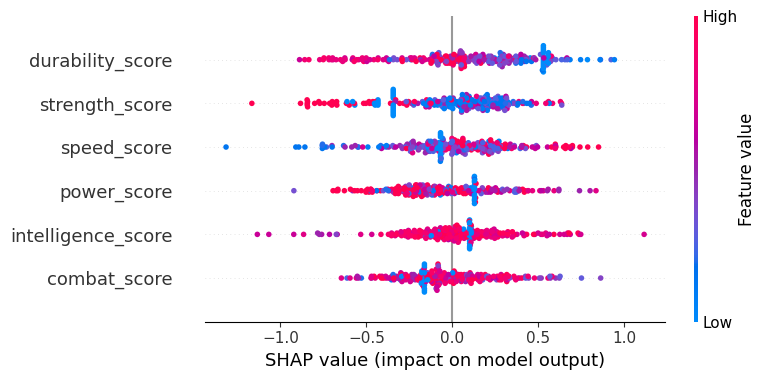

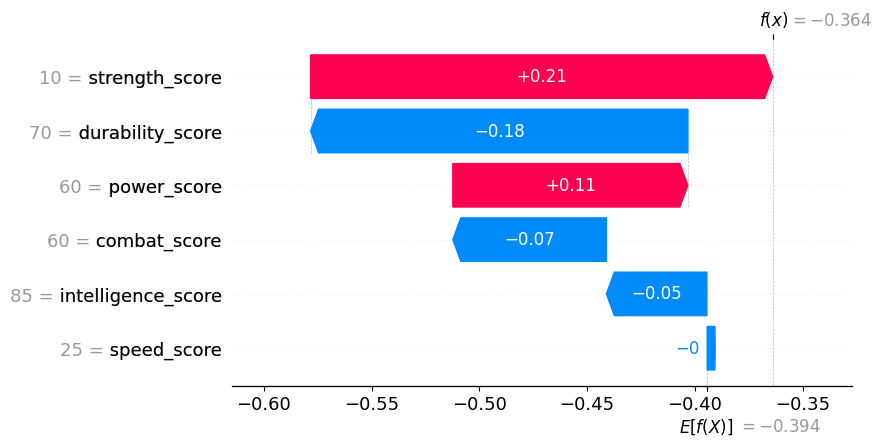

In [38]:
import shap

# Crear explainer y calcular SHAP values
explainer = shap.TreeExplainer(lgbm_interp)
shap_values = explainer(X_test_num)

# Summary plot para la clase "Good"
# En LightGBM multiclase, el orden de clases es alfabético: Bad=0, Good=1, Neutral=2
good_idx = list(lgbm_interp.classes_).index("Good")

shap.summary_plot(shap_values[:, :, good_idx], X_test_num)

# Waterfall plot para una instancia cualquiera
shap.plots.waterfall(shap_values[0, :, good_idx])

In [39]:
print(X_test_num.iloc[0])
print(y_test.iloc[0])
print(df_comics.loc[X_test_num.index[0], "name"])

intelligence_score    85
strength_score        10
speed_score           25
durability_score      70
power_score           60
combat_score          60
Name: 1303, dtype: int64
Bad
The Shocker (MCU)


### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?


1. PFI da una importancia global: permuta cada feature en todo el test set y mide cuánto cae el F1-Macro promedio, sin distinguir entre instancias. SHAP en cambio es local: asigna a cada feature una contribución específica para cada predicción individual, indicando además la dirección del efecto (si empuja hacia Good o away from Good). Con SHAP puedes explicar por qué el modelo predijo lo que predijo para un personaje en particular, algo que PFI no permite.

2. Para The Shocker (MCU) las features que más empujaron la predicción fueron `strength_score` (+0.21, hacia Good) y `durability_score` (-0.18, alejando de Good), seguidas de `power_score` (+0.11) y `combat_score` (-0.07). La predicción final fue "Bad", lo que tiene total sentido: The Shocker es un villano menor del universo Spider-Man, conocido por ser un ladrón sin ningún trasfondo heroico. Su `strength_score` bajo (10) y su alta inteligencia (85) combinada con durabilidad media describen bien a un personaje más técnico que poderoso, y el modelo correctamente lo clasifica como Bad. Es interesante que `strength_score` empuje hacia Good a pesar de ser bajo — probablemente porque el modelo aprendió que valores muy bajos de fuerza son atípicos entre los villanos más poderosos.

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [46]:
# Eliminar NaN en history_text
df_comics_no_label_clean = df_comics_no_label.dropna(subset=["history_text"]).drop_duplicates()

# Predecir con el mejor modelo
predictions = pipe_lgbm_opt.predict(df_comics_no_label_clean)

# Mostrar resultados para los 3 personajes
result_df = df_comics_no_label_clean[["name"]].copy()
result_df["predicted_alignment"] = predictions

print(result_df[result_df["name"].isin(["Vergil", "Gorilla Girl", "Batcow"])])

              name predicted_alignment
122         Batcow                Good
529   Gorilla Girl                Good
1368        Vergil                Good


In [47]:
# Ver scores de los 3 personajes directamente del dataset
personajes = ["Vergil", "Gorilla Girl", "Batcow"]
cols = ["name"] + NUMERICAL_FEATURES

print(df_comics_no_label[df_comics_no_label["name"].isin(personajes)][cols].drop_duplicates())

              name  intelligence_score  strength_score  speed_score  \
122         Batcow                  70              10           25   
529   Gorilla Girl                  90              35           60   
1368        Vergil                  90              75           95   

      durability_score  power_score  combat_score  
122                 20           10            20  
529                 60           45           100  
1368                90          100           100  


### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

1. Las tres predicciones son razonables:

- **Vergil** (Good): Vergil es el antagonista de Devil May Cry, pero con un código de honor muy marcado. Sus scores son altísimos en todo (speed=95, power=100, combat=100, durability=90), lo que lo hace parecerse numéricamente más a un héroe poderoso que a un villano típico, de ahí que el modelo lo clasifique como Good.

- **Gorilla Girl** (Good): Es una superheroína de Marvel que ha sido parte de los Avengers, así que Good es exactamente lo esperado. Sus scores de combat (100) e intelligence (90) son consistentes con un personaje heroico.

- **Batcow** (Good): Es la vaca mascota de Damian Wayne (Robin). Claramente no es un villano, así que Good tiene sentido. Llama la atención que a pesar de tener scores muy bajos (strength=10, durability=20, power=10), el modelo igual predijo Good, lo que sugiere que el texto del historial fue determinante en esta predicción.

2. El waterfall plot que generamos corresponde a The Shocker, donde las features más influyentes fueron `strength_score` y `durability_score`. Aplicando ese mismo patrón a Batcow, sus valores muy bajos en ambas (strength=10, durability=20) deberían alejar la predicción de Good. Sin embargo el modelo igual predijo Good, lo que es consistente con que Batcow es una vaca doméstica sin capacidades de combate pero con un rol claramente benévolo en su historia, capturado principalmente por el texto del historial.

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>